<a href="https://colab.research.google.com/github/SahilRaut80/Assignments/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("amazonreviews.tsv", sep='\t')
df

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df.columns

Index(['label', 'review'], dtype='object')

In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.dropna(subset=['review'])

In [ ]:
df['label'] = df['label'].map({'pos': 1, 'neg': 0})

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)


In [ ]:
df.head()

,label,review,clean_review
0,NaN,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,NaN,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,NaN,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,NaN,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,NaN,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


IndexError: index 0 is out of bounds for axis 0 with size 0

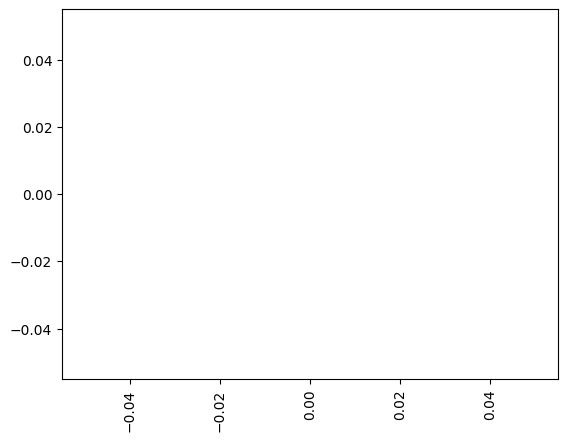

In [ ]:
df['label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xticks([0,1], ['Negative', 'Positive'])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Features
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_review'])
y = df['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
lr = LogisticRegression()
svm = LinearSVC()

# Train
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)


ValueError: Input y contains NaN.

In [ ]:
def evaluate(model, name):
    pred = model.predict(X_test)

    print(f"\n{name} Performance:")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred))
    print(classification_report(y_test, pred))

evaluate(lr, "Logistic Regression")
evaluate(svm, "SVM")


NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
cv_lr = cross_val_score(lr, X, y, cv=5, scoring='f1')
cv_svm = cross_val_score(svm, X, y, cv=5, scoring='f1')

print("LR CV F1:", cv_lr.mean())
print("SVM CV F1:", cv_svm.mean())


/usr/local/lib/python3.13/dist-packages/sklearn/utils/_array_api.py:399: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


ValueError: Input y contains NaN.

In [ ]:
# !pip install gensim


In [ ]:
from gensim.models import Word2Vec
import numpy as np

# Tokenize
tokenized = df['clean_review'].apply(lambda x: x.split())

# Train Word2Vec
w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=2)


In [ ]:
# Convert sentence to vector
def sentence_vector(words):
    vec = np.zeros(100)
    count = 0
    for word in words:
        if word in w2v_model.wv:
            vec += w2v_model.wv[word]
            count += 1
    if count != 0:
        vec /= count
    return vec

X_w2v = np.array([sentence_vector(words) for words in tokenized])



In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42
)

In [ ]:
# Train model
lr.fit(X_train, y_train)

In [ ]:

# Evaluate
pred = lr.predict(X_test)
print("Word2Vec LR Accuracy:", accuracy_score(y_test, pred))